In [1]:
import os
# os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

import sys

sys.path.insert(0, "../..")

In [2]:
import chex
import dill
import jax
import jax.numpy as jnp
import jax.random as jrandom
import json
import math
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
import scipy
import torch
import seaborn as sns

from flax import nnx
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
from typing import Any, NamedTuple
from typing_extensions import Protocol, runtime_checkable

from src.constants import *
from src.dataset import get_iter
from src.datasets.sum import Addition
from src.decoding import make_autoregressive
from src.rollout import rollout, rollout_with_logits
from src.utils import parse_dict
from src.verifier import make_compute_returns

In [3]:
plt.style.use("seaborn-v0_8-colorblind")

### Setup

In [ ]:
base_path = "/home/bryanpu1/projects/parallel_vs_serial/scaling_jax/results"
algo_name = "addition-max_int_64-no_eos-reset_immediately"

# group_name = "algo_compare"
# run_names = {
#     "Traj. Improvement": "ppo-scratch_1M-traj_improvement_fixed-discounting-0_cot_tokens-8x8-01-25-26_07_52_41-cfc6a873-9c41-4c29-9dac-d83eb011a4f9",
#     "Vanilla PPO": "ppo_kl-scratch_1M-0_cot_tokens-8x8-01-23-26_11_05_40-93cc131e-8f27-4175-88b1-51de541e4d0b",
#     "Meta RL": "ppo-scratch_1M-meta_rl-0_cot_tokens-8x8-01-23-26_11_08_43-9a5c8346-6c12-4081-9a21-24acf4c0133d",
#     "Off-policy Context PPO": "opc_ppo-scratch_1M-0_cot_tokens-8x8-01-26-26_07_00_51-eaee1709-185a-4366-938f-752d2aefd1ea",
#     "Off-policy Context Traj. Improvement": "opc_ppo-scratch_1M-traj_improvement-0_cot_tokens-8x8-01-26-26_06_57_54-72a716da-5119-4bad-92d3-d498cbe06d27",
#     "Progress PPO": "ppo-scratch_1M-progress_rl-0_cot_tokens-8x8-01-25-26_07_51_57-6bd6ac0b-f1ec-4a21-a1e2-3c973f0a4b7b",
# }

# group_name = "algo_efficiency"
# run_names = {
#     "Vanilla PPO": "ppo_kl-scratch_1M-0_cot_tokens-8x8-01-23-26_11_05_40-93cc131e-8f27-4175-88b1-51de541e4d0b",
#     "Off-policy Context PPO": "opc_ppo-scratch_1M-0_cot_tokens-8x8-01-26-26_07_00_51-eaee1709-185a-4366-938f-752d2aefd1ea",
#     "Traj. Improvement": "ppo-scratch_1M-traj_improvement_fixed-discounting-0_cot_tokens-8x8-01-25-26_07_52_41-cfc6a873-9c41-4c29-9dac-d83eb011a4f9",
#     "Off-policy Context Traj. Improvement": "opc_ppo-scratch_1M-traj_improvement-0_cot_tokens-8x8-01-26-26_06_57_54-72a716da-5119-4bad-92d3-d498cbe06d27",
# }

# checkpoint_i = 10
checkpoint_i = -1

# group_name = "opc_traj_improve_ablation"
# run_names = {
#     "Save all attempts": "opc_ppo-scratch_1M-traj_improvement-0_cot_tokens-8x8-01-26-26_06_57_54-72a716da-5119-4bad-92d3-d498cbe06d27",
#     "Save failure attempts": "opc_ppo-scratch_1M-save_when_failure-traj_improvement-0_cot_tokens-8x8-01-29-26_09_47_18-f455d153-6b0f-442c-ab97-c4d256a9b18f",
#     "Default": "opc_ppo-scratch_1M-save_when_multiple_attempts-traj_improvement-0_cot_tokens-8x8-01-27-26_12_59_40-73ff08af-b185-42ca-b43c-d78b3a750567",
#     "W/ clip higher": "opc_ppo-scratch_1M-clip_high-save_when_multiple_attempts-traj_improvement-0_cot_tokens-8x8-01-27-26_15_12_47-b69126b6-368a-4996-bb6f-9426b87306c1",
#     "W/ quiet softmax": "opc_ppo-scratch_1M-quiet_softmax-save_when_multiple_attempts-traj_improvement-0_cot_tokens-8x8-01-29-26_03_45_34-6e3fd224-57a3-4b34-872d-b37dab229352",
# }
# checkpoint_i = -1

group_name = "train_on_all_ablation"
run_names = {
    "Train on subset": "opc_ppo-scratch_1M-save_when_multiple_attempts-traj_improvement-0_cot_tokens-8x8-01-27-26_12_59_40-73ff08af-b185-42ca-b43c-d78b3a750567",
    "Default": "opc_ppo-scratch_1M-include_all_in_len_examples-save_when_multiple_attempts-traj_improvement-0_cot_tokens-8x8-02-02-26_07_10_26-0d777242-30c2-4a8a-8ad9-31fcb7eff01b",
    "Discourage first reset": "opc_ppo-scratch_1M-discourage_first_reset-include_all_in_len_examples-save_when_multiple_attempts-traj_improvement-0_cot_tokens-8x8-02-03-26_10_19_14-c2e9addf-156e-4b77-b352-d03eaade5e43",
    "Zero on reset": "opc_ppo-scratch_1M-zero_on_reset_discourage_first_reset-include_all_in_len_examples-save_when_multiple_attempts-traj_improvement-0_cot_tokens-8x8-02-06-26_03_30_40-ca2237d4-d1e0-425d-bd5a-4a4a50023adb",
}
# checkpoint_i = -1

hide_question = False
# hide_question = True

# num_evals = 1
# max_response_length = 500

num_evals = 128
max_response_length = 200

# batch_size = 100
batch_size = 500

eval_seed = 42
max_bits = 12
batch_size_per_block = 50
max_decode_len = max_response_length if hide_question else 2 * max_bits + 1 + max_response_length

In [5]:
learner_path = os.path.join(base_path, algo_name, list(run_names.values())[0])
config_dict = json.load(open(os.path.join(learner_path, "config.json"), "r"))
half_precision = config_dict["half_precision"]
dtype = jnp.bfloat16 if half_precision else jnp.float32

# Get dataset
max_int = int(2 ** max_bits)
config = parse_dict(config_dict)
dataset_kwargs = config.dataset_kwargs

pass_k_save_name = "attempt_diversity_results-pass_k-{}-checkpoint_{}-max_response_length_{}{}{}.dill".format(
    group_name,
    checkpoint_i * config.logging_config.checkpoint_interval if checkpoint_i >= 0 else "last",
    max_response_length,
    "-hide_question" if hide_question else "",
    "-deterministic" if num_evals == 1 else "",
)

checkpoint_save_name = "attempt_diversity_results-all_checkpoints-{}-k_{}-max_response_length_{}{}{}.dill".format(
    group_name,
    num_evals,
    max_response_length,
    "-hide_question" if hide_question else "",
    "-deterministic" if num_evals == 1 else "",
)

logits_save_name = "attempt_diversity_results-logits-{}-k_{}-max_response_length_{}{}{}.dill".format(
    group_name,
    num_evals,
    max_response_length,
    "-hide_question" if hide_question else "",
    "-deterministic" if num_evals == 1 else "",
)

traj_save_name = "attempt_diversity_results-traj-{}-k_{}-max_response_length_{}{}{}.dill".format(
    group_name,
    num_evals,
    max_response_length,
    "-hide_question" if hide_question else "",
    "-deterministic" if num_evals == 1 else "",
)

In [6]:
if config.dataset_name == "curriculum":
    train_num_bits = int(np.ceil(np.log2(dataset_kwargs.datasets[-1]["dataset_kwargs"]["max_int"])))
    train_val_ratio = dataset_kwargs.datasets[-1]["dataset_kwargs"]["train_val_ratio"]
    predict_eos = dataset_kwargs.datasets[-1]["dataset_kwargs"]["predict_eos"]
    num_cot_tokens = dataset_kwargs.datasets[-1]["dataset_kwargs"]["num_cot_tokens"]
    right_to_left = dataset_kwargs.datasets[-1]["dataset_kwargs"]["right_to_left"]
    correctness_aware = dataset_kwargs.datasets[-1]["dataset_kwargs"]["correctness_aware"]
    carry_registers = dataset_kwargs.datasets[-1]["dataset_kwargs"]["carry_registers"]
    train_max_decode_len = dataset_kwargs.datasets[-1]["dataset_kwargs"]["context_len"]
else:
    train_num_bits = int(np.ceil(np.log2(dataset_kwargs.max_int)))
    train_val_ratio = dataset_kwargs.train_val_ratio
    predict_eos = dataset_kwargs.predict_eos
    num_cot_tokens = dataset_kwargs.num_cot_tokens
    right_to_left = dataset_kwargs.right_to_left
    correctness_aware = dataset_kwargs.correctness_aware
    carry_registers = getattr(dataset_kwargs, "carry_registers", False)
    train_max_decode_len = dataset_kwargs.context_len

dataset = Addition(
    context_len=max_decode_len,
    max_int=max_int,
    train=True,
    seed=eval_seed,
    sequence_type="question_only",
    train_val_ratio=1.0,
    right_to_left=right_to_left,
    num_repeats=1,
    shuffle=True,
    exact=True,
    predict_eos=predict_eos,
    num_cot_tokens=num_cot_tokens,
    p_curriculum=0.0,
    p_inject_noop=0.0,
    max_noops=0,
    noop_as_pad=False,
    reverse_curriculum=False,
    correctness_aware=correctness_aware,
    carry_registers=carry_registers,
)

out_dim = int(dataset.output_space.n)
data_loader = DataLoader(
    dataset,
    batch_size=batch_size_per_block,
    num_workers=0,
)
data_iter = get_iter(data_loader, None, dtype)

EOS TOKEN: 6
TOKEN MAP: {0: 0, 1: 1, 2: 2, 3: 3, 6: 6, 4: 4, 5: 5}


In [7]:
for exp_name, run_name in run_names.items():
    learner_path = os.path.join(base_path, algo_name, run_name)
    print("{} {}".format(exp_name, sorted(os.listdir(os.path.join(learner_path, "models")))))

Train on subset ['0000000.dill', '0050000.dill', '0100000.dill', '0150000.dill', '0200000.dill', '0250000.dill', '0300000.dill', '0350000.dill', '0400000.dill', '0450000.dill', '0500000.dill', '0550000.dill', '0600000.dill', '0650000.dill', '0700000.dill', '0750000.dill', '0800000.dill', '0850000.dill', '0900000.dill', '0950000.dill', '1000000.dill']
Default ['0000000.dill', '0050000.dill', '0100000.dill', '0150000.dill', '0200000.dill', '0250000.dill', '0300000.dill', '0350000.dill', '0400000.dill', '0450000.dill', '0500000.dill', '0550000.dill', '0600000.dill', '0650000.dill', '0700000.dill', '0750000.dill', '0800000.dill', '0850000.dill', '0900000.dill', '0950000.dill', '1000000.dill']
Discourage first reset ['0000000.dill', '0050000.dill', '0100000.dill', '0150000.dill', '0200000.dill', '0250000.dill', '0300000.dill', '0350000.dill', '0400000.dill', '0450000.dill', '0500000.dill', '0550000.dill', '0600000.dill', '0650000.dill', '0700000.dill', '0750000.dill', '0800000.dill', '08500

In [8]:
def compute_expected_trials(batch_i, batch):
    action_ordering = jax.vmap(lambda rng: jrandom.permutation(
        rng,
        out_dim,
    ))(
        jrandom.split(
            jrandom.fold_in(jrandom.PRNGKey(eval_seed), 0),
            batch_size_per_block * num_evals * max_response_length,
        )
    )
    action_ordering = action_ordering.reshape((batch_size_per_block * num_evals, max_response_length, out_dim))
    action_ordering = jnp.transpose(action_ordering, (2, 1, 0))

    @jax.jit
    def _match_bits(bits, curr_action):
        return bits == curr_action

    match_bits = jax.vmap(_match_bits, in_axes=[None, 0])

    def _get_num_tries(prev_count, curr_bit):
        match_bit_mask = match_bits(
            jnp.array(batch["target"])[:, curr_bit],
            action_ordering[:, curr_bit],
        )

        pred_mask = jnp.array(batch["solution_len"]) >= (curr_bit + 1)

        match_bit_mask *= jnp.arange(1, 1 + out_dim)[:, None]
        match_bit_mask = pred_mask * jnp.sum(match_bit_mask, axis=0)
        retry_length = match_bit_mask * (curr_bit + 1)
        curr_count = prev_count + jnp.concatenate(
            (match_bit_mask[:, None], retry_length[:, None]),
            axis=-1,
        )
        return curr_count, curr_count

    num_retries, counts = jax.lax.scan(
        _get_num_tries,
        jnp.zeros((len(batch["target"]), 2), dtype=int),
        jnp.arange(max_response_length),
    )
    return num_retries.T

In [9]:
def compute_wilson_ci(n, acc):
    # alpha = 0.05
    base = (n * acc + 0.5 * 3.841) / (n + 3.841)
    err = np.sqrt(3.841) / (n + 3.841) * np.sqrt(n * acc * (1 - acc) + 0.25 * 3.841)

    return (base - err, base + err)

def compute_normal_ci(n, arr):
    # alpha = 0.05
    mean_arr = np.mean(arr)
    std_arr = np.std(arr)
    ci = 1.96 * std_arr / np.sqrt(n)
    return (mean_arr - ci, mean_arr + ci)

In [10]:
assert 0

AssertionError: 

## Check Pass@K at different K

In [ ]:
if os.path.isfile(pass_k_save_name):
    results = dill.load(open(pass_k_save_name, "rb"))
else:
    results = dict()

    for batch_i in tqdm(range(batch_size // batch_size_per_block)):
        batch = next(data_iter)

        if hide_question:
            batch["sequence"][:] = dataset.reset_token_id
            batch["mask"][:] = 1
            batch["question_len"][:] = 0

        batch = {
            k: np.repeat(v, num_evals, axis=0)
            for k, v in batch.items()
        }

        curr_result = compute_expected_trials(batch_i, batch)
        curr_result = np.vstack((
            np.array(curr_result[1] <= max_response_length),
            np.array(curr_result[1]),
            np.array(curr_result[0]),
        ), dtype=int)
        if batch_i == 0:
            results["BFS"] = curr_result
        else:
            results["BFS"] = np.hstack((results["BFS"], curr_result))

        for exp_name, run_name in run_names.items():
            learner_path = os.path.join(base_path, algo_name, run_name)
            config_dict = json.load(open(os.path.join(learner_path, "config.json"), "r"))

            # Load model
            last_step = sorted(os.listdir(os.path.join(learner_path, "models")))[checkpoint_i]
            if batch_i == 0:
                print(exp_name, last_step)
            train_state = dill.load(
                open(os.path.join(learner_path, "models", last_step), "rb")
            )

            model = nnx.merge(
                train_state.graphdef,
                train_state.params,
                train_state.rest,
            )

            rng = jax.random.PRNGKey(eval_seed)
            rng, rollout_rng = jax.random.split(rng)

            # Sample next batch and evaluate
            _, init_cache = make_autoregressive(
                model,
                max_decode_len=max_decode_len,
                batch_size=batch_size_per_block * num_evals,
                embed_dim=config_dict["model_config"]["model_kwargs"]["embed_dim"],
                dtype=dtype,
                eval_mode=True,
            )
            cache = init_cache()
            graphdef, _, rest = nnx.split(model, nnx.Cache, ...)

            rollout_res = rollout(
                graphdef,
                cache,
                rest,
                rollout_rng,
                batch,
                eos_token=dataset.eos_token_id,
                deterministic=int(num_evals == 1),
                correct_aware_shift=dataset.correctness_aware_tokens_offset,
                max_token_id_to_shift=dataset.max_token_id_to_shift,
            )

            num_resets = np.sum((rollout_res.observations * rollout_res.pred_mask) == dataset.reset_token_id, axis=-1)

            curr_result = np.vstack((
                np.array(rollout_res.success),
                np.array(rollout_res.response_length),
                np.array(num_resets),
            ), dtype=int)
            if batch_i == 0:
                results[exp_name] = curr_result
            else:
                results[exp_name] = np.hstack((results[exp_name], curr_result))

    dill.dump(
        results,
        open(pass_k_save_name, "wb"),
    )

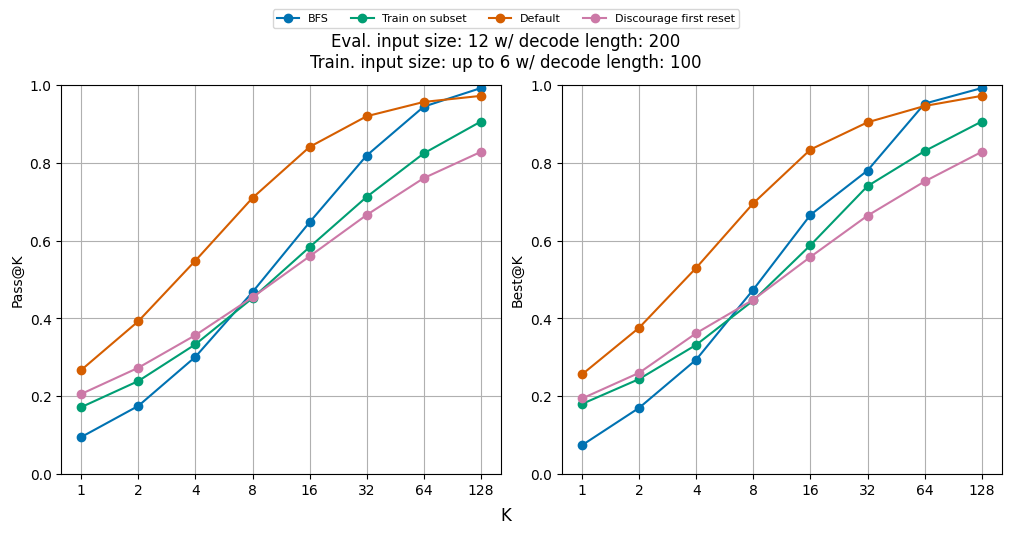

In [ ]:
if num_evals > 1:
    x_range = np.arange(math.ceil(np.log2(num_evals)) + 1)
    ns = np.full((batch_size, len(x_range)), fill_value=num_evals)
    ks = np.repeat((2 ** x_range)[None], batch_size, axis=0)
    num_cols = 2
    num_rows = 1
    fig, axes = plt.subplots(num_rows, num_cols, layout="constrained", figsize=(5.0 * num_cols, 5.0 * num_rows))
    for i, (exp_name, res_array) in enumerate(results.items()):
        success_array = res_array[0].reshape((batch_size, num_evals))
        pass_k = np.mean(
            1 - scipy.special.comb(
                ns - np.repeat(np.sum(success_array, axis=-1, keepdims=True), len(x_range), axis=1),
                ks,
                exact=False,
            ) / scipy.special.comb(ns, ks, exact=False), axis=0)
        best_k = np.mean(np.maximum.accumulate(success_array, axis=-1), axis=0)

        scatter = axes[0].plot(
            x_range,
            pass_k[x_range],
            label=exp_name,
            marker="o",
        )

        scatter = axes[1].plot(
            x_range,
            best_k[2 ** x_range - 1],
            marker="o",
        )

    axes[0].set_xticks(x_range)
    axes[0].set_xticklabels(2 ** x_range)
    axes[0].set_ylabel("Pass@K")
    axes[0].set_ylim(0.0, 1.0)
    axes[0].grid(True)
    axes[1].set_xticks(x_range)
    axes[1].set_xticklabels(2 ** x_range)
    axes[1].set_ylabel("Best@K")
    axes[1].set_ylim(0.0, 1.0)
    axes[1].grid(True)
    
    fig.suptitle("Eval. input size: {} w/ decode length: {}\nTrain. input size: up to {} w/ decode length: {}".format(
        max_bits,
        max_response_length,
        train_num_bits,
        train_max_decode_len,
    ))
    fig.supxlabel("K")
    fig.legend(
        bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
        loc="lower center",
        ncols=4,
        borderaxespad=0.0,
        frameon=True,
        fontsize="8",
    )
else:
    num_cols = 1
    num_rows = 1
    fig, ax = plt.subplots(num_rows, num_cols, layout="constrained", figsize=(5.0 * num_cols, 5.0 * num_rows))
    success_rates = []
    exp_names = []
    for i, (exp_name, res_array) in enumerate(results.items()):
        success_array = res_array[0].reshape((batch_size, num_evals))
        success_rates.append(np.mean(success_array))
        exp_names.append(exp_name)

    x_range = np.arange(len(success_rates))
    ax.bar(
        x_range,
        success_rates,
    )
    ax.set_xticks(x_range, exp_names, rotation=30, ha="right")
    ax.set_ylim(0.0, 1.0)
    ax.grid(True)

    fig.suptitle("Eval. input size: {} w/ decode length: {}\nTrain. input size: up to {} w/ decode length: {}".format(
        max_bits,
        max_response_length,
        train_num_bits,
        train_max_decode_len,
    ))
    fig.supxlabel("Model")
    fig.supylabel("Greedy decoding success rate")
    fig.legend(
        bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
        loc="lower center",
        ncols=4,
        borderaxespad=0.0,
        frameon=True,
        fontsize="8",
    )

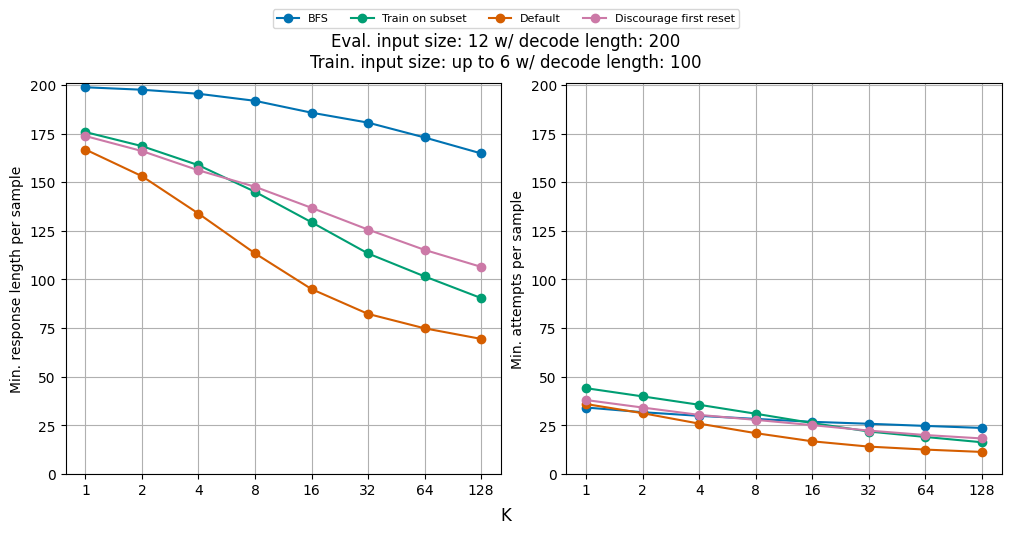

In [ ]:
if num_evals > 1:
    x_range = np.arange(math.ceil(np.log2(num_evals)) + 1)
    num_cols = 2
    num_rows = 1
    fig, axes = plt.subplots(num_rows, num_cols, layout="constrained", figsize=(5.0 * num_cols, 5.0 * num_rows))

    for i, (exp_name, res_array) in enumerate(results.items()):
        success_array = res_array[0].reshape((batch_size, num_evals))
        rlength_array = res_array[1].reshape((batch_size, num_evals))
        reset_array = res_array[2].reshape((batch_size, num_evals))
        try:
            rlength_array = rlength_array.at[jnp.logical_not(success_array)].set(max_response_length)
        except:
            rlength_array[jnp.logical_not(success_array)] = max_response_length
        min_response_length_per_sample = np.minimum.accumulate(rlength_array, axis=-1)
        min_response_length = np.mean(min_response_length_per_sample, axis=0)
        min_attempt_per_sample = np.minimum.accumulate(reset_array, axis=-1)
        min_attempt = np.mean(min_attempt_per_sample, axis=0)
        mean_attempt_per_sample = np.cumsum(reset_array, axis=-1) / np.arange(1, num_evals + 1)
        mean_attempt = np.mean(mean_attempt_per_sample, axis=0)

        scatter = axes[0].plot(
            x_range,
            min_response_length[2 ** x_range - 1],
            label=exp_name,
            marker="o",
        )
        axes[0].set_xticks(x_range)
        axes[0].set_xticklabels(2 ** x_range)
        axes[0].set_ylabel("Min. response length per sample")
        axes[0].set_ylim(0.0, max_response_length + 1)
        axes[0].grid(True)

        scatter = axes[1].plot(
            x_range,
            min_attempt[2 ** x_range - 1],
            marker="o",
        )
        axes[1].set_xticks(x_range)
        axes[1].set_xticklabels(2 ** x_range)
        axes[1].set_ylabel("Min. attempts per sample")
        axes[1].grid(True)
        axes[1].set_ylim(0.0, max_response_length + 1)

    fig.supxlabel("K")
    
    fig.suptitle("Eval. input size: {} w/ decode length: {}\nTrain. input size: up to {} w/ decode length: {}".format(
        max_bits,
        max_response_length,
        train_num_bits,
        train_max_decode_len,
    ))
    fig.legend(
        bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
        loc="lower center",
        ncols=4,
        borderaxespad=0.0,
        frameon=True,
        fontsize="8",
    )
else:
    num_cols = 2
    num_rows = 1
    fig, axes = plt.subplots(num_rows, num_cols, layout="constrained", figsize=(5.0 * num_cols, 5.0 * num_rows))
    rlengths = []
    resets = []
    exp_names = []
    for i, (exp_name, res_array) in enumerate(results.items()):
        rlength_array = res_array[1].reshape((batch_size, num_evals))
        reset_array = res_array[2].reshape((batch_size, num_evals))
        rlengths.append(np.mean(rlength_array))
        resets.append(np.mean(reset_array))
        exp_names.append(exp_name)

    x_range = np.arange(len(exp_names))
    axes[0].bar(
        x_range,
        rlengths,
    )
    axes[0].set_xticks(x_range, exp_names, rotation=30, ha="right")
    axes[0].set_ylabel("Min. response length per sample")
    axes[0].set_ylim(0.0, max_response_length + 1)
    axes[0].grid(True)

    axes[1].bar(
        x_range,
        resets,
    )
    axes[1].set_xticks(x_range, exp_names, rotation=30, ha="right")
    axes[1].set_ylabel("Min. attempts per sample")
    axes[1].set_ylim(0.0, max_response_length + 1)
    axes[1].grid(True)

    fig.suptitle("Eval. input size: {} w/ decode length: {}\nTrain. input size: up to {} w/ decode length: {}".format(
        max_bits,
        max_response_length,
        train_num_bits,
        train_max_decode_len,
    ))
    fig.supxlabel("Model")
    fig.legend(
        bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
        loc="lower center",
        ncols=4,
        borderaxespad=0.0,
        frameon=True,
        fontsize="8",
    )

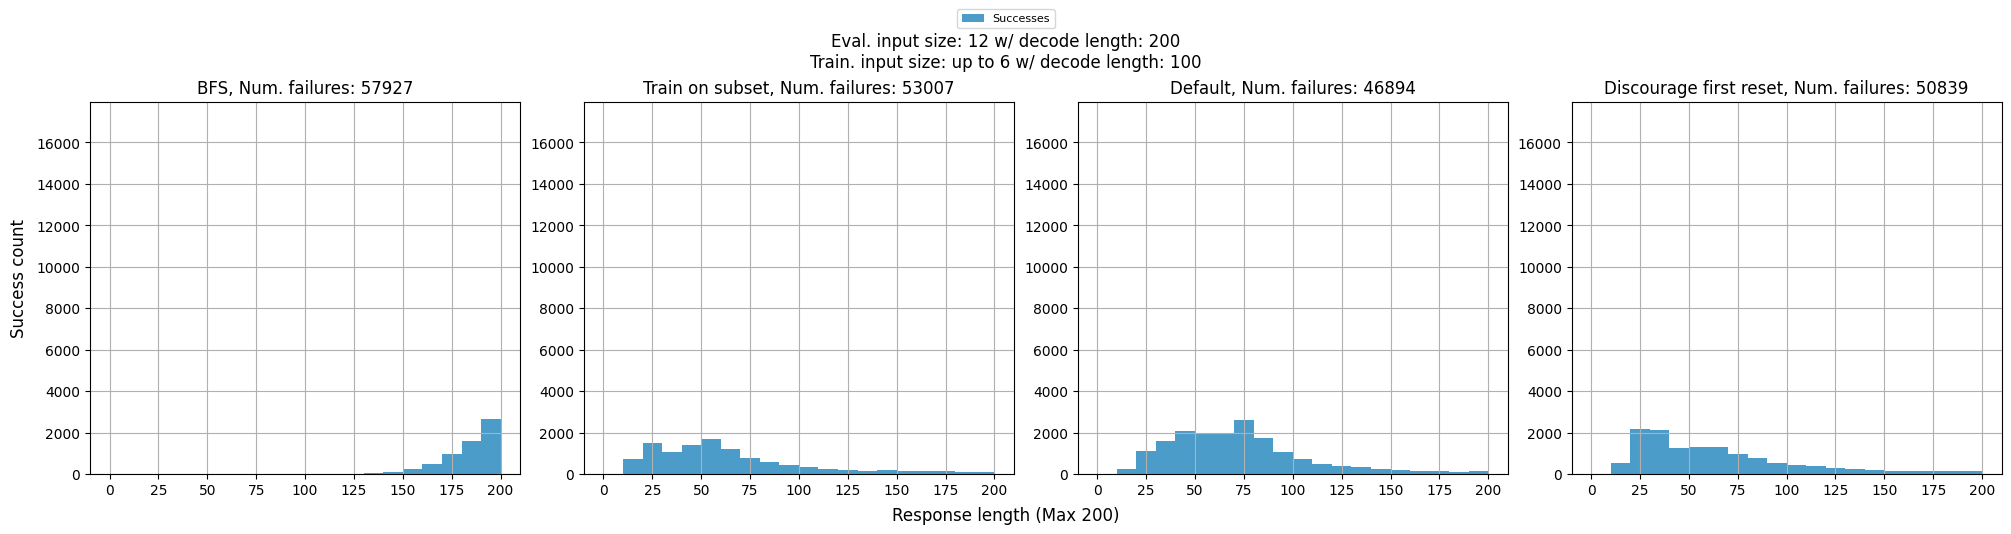

In [ ]:
num_cols = 4
num_rows = math.ceil(len(results) / num_cols)
fig, axes = plt.subplots(num_rows, num_cols, layout="constrained", figsize=(5.0 * num_cols, 5.0 * num_rows))

delta = 10
axes = axes.flatten()
max_success = max([np.sum(res_array[0], axis=-1) for (exp_name, res_array) in results.items() if exp_name != "BFS"])
max_failure = max([np.sum(1 - res_array[0], axis=-1) for (exp_name, res_array) in results.items() if exp_name != "BFS"])
for i, (exp_name, res_array) in enumerate(results.items()):
    success_array = res_array[0]
    rlength_array = res_array[1]
    success_only_rlength = rlength_array[np.where(success_array)]
    failure_only_rlength = np.sum(np.logical_not(success_array))

    counts, bins = np.histogram(success_only_rlength, bins=np.arange(0, max_response_length + delta, delta))
    scatter = axes[i].hist(bins[:-1], bins, weights=counts, color="C0", alpha=0.7, label="Successes" if i == 0 else "")

    axes[i].set_ylim(0, max_success * 1.05)
    axes[i].set_title("{}, Num. failures: {}".format(exp_name, failure_only_rlength))
    axes[i].grid(True)

for i in range(len(results), num_cols * num_rows):
    axes[i].axis("off")

fig.supylabel("Success count")
fig.supxlabel("Response length (Max {})".format(max_response_length))
fig.suptitle("Eval. input size: {} w/ decode length: {}\nTrain. input size: up to {} w/ decode length: {}".format(
    max_bits,
    max_response_length,
    train_num_bits,
    train_max_decode_len,
))
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=4,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

In [ ]:
assert 0

AssertionError: 

## With and without questions
This tests whether or not the model can effectively leverage contextual information (its question) for less attempts. Without the questions we can see whether or not the model can simply explore the solution space effectively.


In [ ]:
with_question_pass_k_save_name = "attempt_diversity_results-pass_k-{}-checkpoint_{}-max_response_length_{}{}.dill".format(
    group_name,
    checkpoint_i * config.logging_config.checkpoint_interval if checkpoint_i >= 0 else "last",
    max_response_length,
    "-deterministic" if num_evals == 1 else "",
)
hide_question_pass_k_save_name = "attempt_diversity_results-pass_k-{}-checkpoint_{}-max_response_length_{}-hide_question{}.dill".format(
    group_name,
    checkpoint_i * config.logging_config.checkpoint_interval if checkpoint_i >= 0 else "last",
    max_response_length,
    "-deterministic" if num_evals == 1 else "",
)

with_question_results = dill.load(open(with_question_pass_k_save_name, "rb"))
hide_question_results = dill.load(open(hide_question_pass_k_save_name, "rb"))

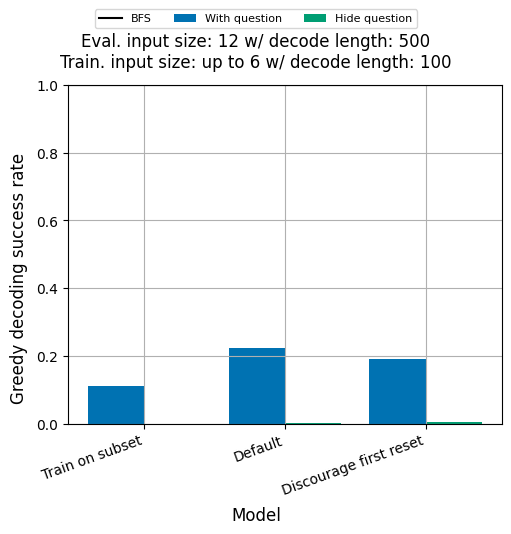

In [ ]:
if num_evals > 1:
    x_range = np.arange(math.ceil(np.log2(num_evals)) + 1)
    ns = np.full((batch_size, len(x_range)), fill_value=num_evals)
    ks = np.repeat((2 ** x_range)[None], batch_size, axis=0)
    num_cols = 3
    num_rows = math.ceil(len(run_names) / 3)
    fig, axes = plt.subplots(num_rows, num_cols, layout="constrained", figsize=(5.0 * num_cols, 5.0 * num_rows))

    axes = axes.flatten()
    for i, exp_name in enumerate(run_names):

        with_q_success_array = with_question_results[exp_name][0].reshape((batch_size, num_evals))
        hide_q_success_array = hide_question_results[exp_name][0].reshape((batch_size, num_evals))


        with_q_pass_k = np.mean(
            1 - scipy.special.comb(
                ns - np.repeat(np.sum(with_q_success_array, axis=-1, keepdims=True), len(x_range), axis=1),
                ks,
                exact=False,
            ) / scipy.special.comb(ns, ks, exact=False), axis=0)
        hide_q_pass_k = np.mean(
            1 - scipy.special.comb(
                ns - np.repeat(np.sum(hide_q_success_array, axis=-1, keepdims=True), len(x_range), axis=1),
                ks,
                exact=False,
            ) / scipy.special.comb(ns, ks, exact=False), axis=0)

        scatter = axes[i].plot(
            x_range,
            with_q_pass_k[x_range],
            label="With question" if i == 0 else "",
            marker="o",
        )

        scatter = axes[i].plot(
            x_range,
            hide_q_pass_k[x_range],
            label="Hide question" if i == 0 else "",
            marker="x",
        )

        improvement = (with_q_pass_k[x_range] - hide_q_pass_k[x_range])
        max_y = max(with_q_pass_k[x_range][-1], hide_q_pass_k[x_range][-1])
        min_y = min(with_q_pass_k[x_range][-1], hide_q_pass_k[x_range][-1])
        axes[i].axvline(x_range[-1], ymin=min_y, ymax=max_y, c="black")
        axes[i].text(
            x_range[-1] + 0.1,
            (max_y + min_y) / 2,
            "{}{:.2f}".format("+" if improvement[-1] >= 0 else "-", np.abs(improvement[-1])),
            rotation=90,
            verticalalignment="center",
        )

        axes[i].set_title(exp_name)
        axes[i].set_xticks(x_range)
        axes[i].set_xticklabels(2 ** x_range)
        axes[i].set_ylim(0.0, 1.0)
        axes[i].grid(True)

    for i in range(len(run_names), num_cols * num_rows):
        axes[i].axis("off")
    fig.supylabel("Pass@K")
    fig.supxlabel("K")
    fig.suptitle("Eval. input size: {} w/ decode length: {}\nTrain. input size: up to {} w/ decode length: {}".format(
        max_bits,
        max_response_length,
        train_num_bits,
        train_max_decode_len,
    ))
    fig.legend(
        bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
        loc="lower center",
        ncols=3,
        borderaxespad=0.0,
        frameon=True,
        fontsize="8",
    )
else:
    num_cols = 1
    num_rows = 1
    fig, ax = plt.subplots(num_rows, num_cols, layout="constrained", figsize=(5.0 * num_cols, 5.0 * num_rows))
    with_q_success_rates = []
    hide_q_success_rates = []
    exp_names = []
    for i, exp_name in enumerate(run_names):

        with_q_success_array = with_question_results[exp_name][0]
        hide_q_success_array = hide_question_results[exp_name][0]
        with_q_pass_k = np.mean(with_q_success_array)
        hide_q_pass_k = np.mean(hide_q_success_array)
        with_q_success_rates.append(with_q_pass_k)
        hide_q_success_rates.append(hide_q_pass_k)
        exp_names.append(exp_name)

    x_range = np.arange(len(exp_names))
    ax.bar(
        x_range - 0.2,
        with_q_success_rates,
        width=0.4,
        align="center",
        label="With question",
    )
    ax.bar(
        x_range + 0.2,
        hide_q_success_rates,
        width=0.4,
        align="center",
        label="Hide question",
    )
    ax.axhline(np.mean(with_question_results["BFS"][0]), label="BFS", c="black")
    ax.set_xticks(x_range, exp_names, rotation=20, ha="right")
    ax.set_ylim(0.0, 1.0)
    ax.grid(True)

    fig.suptitle("Eval. input size: {} w/ decode length: {}\nTrain. input size: up to {} w/ decode length: {}".format(
        max_bits,
        max_response_length,
        train_num_bits,
        train_max_decode_len,
    ))
    fig.supxlabel("Model")
    fig.supylabel("Greedy decoding success rate")
    fig.legend(
        bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
        loc="lower center",
        ncols=4,
        borderaxespad=0.0,
        frameon=True,
        fontsize="8",
    )

In [ ]:
assert 0

AssertionError: 

## Prefix with partial solution

In [ ]:
assert 0

## Learning efficiency

In [11]:
if os.path.isfile(checkpoint_save_name):
    results = dill.load(open(checkpoint_save_name, "rb"))
else:
    results = dict()

    for batch_i in tqdm(range(batch_size // batch_size_per_block)):
        batch = next(data_iter)

        if hide_question:
            batch["sequence"][:] = dataset.reset_token_id
            batch["mask"][:] = 1
            batch["question_len"][:] = 0

        batch = {
            k: np.repeat(v, num_evals, axis=0)
            for k, v in batch.items()
        }

        curr_result = compute_expected_trials(batch_i, batch)
        curr_result = np.vstack((
            np.array(curr_result[1] <= max_response_length),
            np.array(curr_result[1]),
            np.array(curr_result[0]),
        ), dtype=int)
        if batch_i == 0:
            results["BFS"] = curr_result
        else:
            results["BFS"] = np.hstack((results["BFS"], curr_result))

        for exp_name, run_name in run_names.items():
            learner_path = os.path.join(base_path, algo_name, run_name)
            config_dict = json.load(open(os.path.join(learner_path, "config.json"), "r"))

            results.setdefault(exp_name, {})
            if batch_i == 0:
                print(exp_name)
            for step in sorted(os.listdir(os.path.join(learner_path, "models"))):
                # Load model
                train_state = dill.load(
                    open(os.path.join(learner_path, "models", step), "rb")
                )

                model = nnx.merge(
                    train_state.graphdef,
                    train_state.params,
                    train_state.rest,
                )

                rng = jax.random.PRNGKey(eval_seed)
                rng, rollout_rng = jax.random.split(rng)

                # Sample next batch and evaluate
                _, init_cache = make_autoregressive(
                    model,
                    max_decode_len=max_decode_len,
                    batch_size=batch_size_per_block * num_evals,
                    embed_dim=config_dict["model_config"]["model_kwargs"]["embed_dim"],
                    dtype=dtype,
                    eval_mode=True,
                )
                cache = init_cache()
                graphdef, _, rest = nnx.split(model, nnx.Cache, ...)

                rollout_res = rollout(
                    graphdef,
                    cache,
                    rest,
                    rollout_rng,
                    batch,
                    eos_token=dataset.eos_token_id,
                    deterministic=int(num_evals == 1),
                    correct_aware_shift=dataset.correctness_aware_tokens_offset,
                    max_token_id_to_shift=dataset.max_token_id_to_shift,
                )

                num_resets = np.sum((rollout_res.observations * rollout_res.pred_mask) == dataset.reset_token_id, axis=-1)

                success_array = rollout_res.success.reshape((batch_size_per_block, num_evals))
                rlength_array = rollout_res.response_length.reshape((batch_size_per_block, num_evals))
                reset_array = num_resets.reshape((batch_size_per_block, num_evals))

                num_success = np.sum(success_array, axis=-1)
                min_response_length = np.min(rlength_array, axis=-1)
                min_attempt = np.min(reset_array, axis=-1)

                curr_result = np.vstack([num_success, min_response_length, min_attempt])
                if batch_i == 0:
                    results[exp_name][step] = curr_result
                else:
                    results[exp_name][step] = np.hstack((results[exp_name][step], curr_result))

    dill.dump(
        results,
        open(checkpoint_save_name, "wb"),
    )

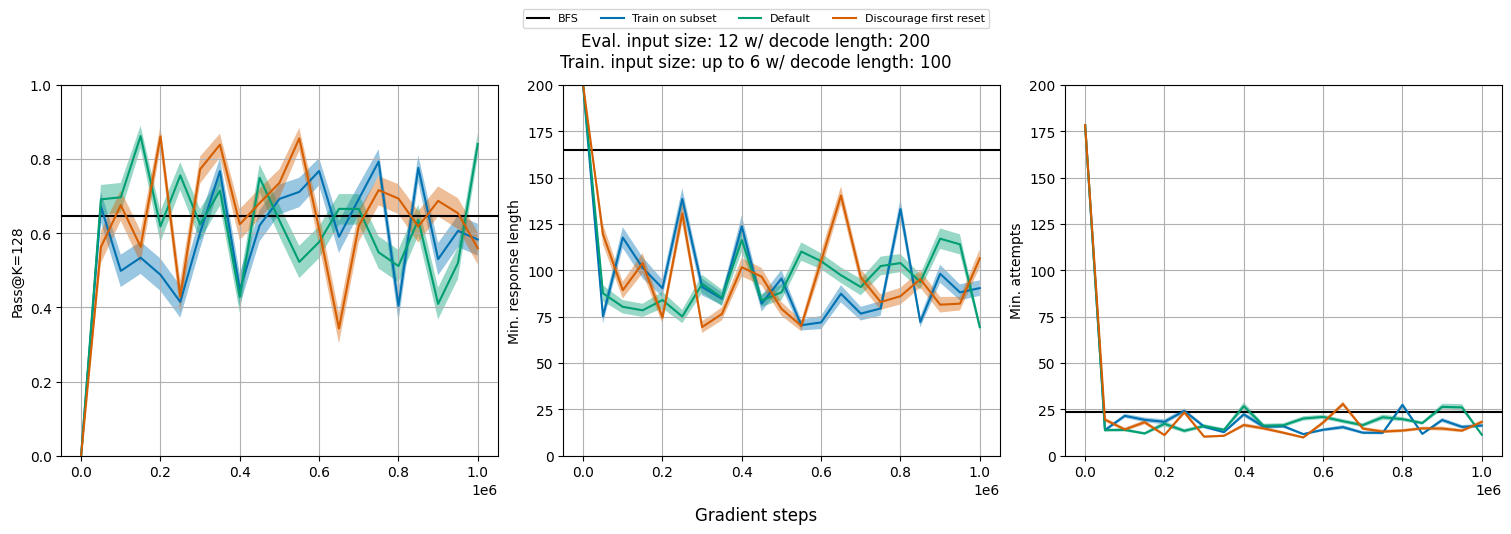

In [17]:
ns = np.full((batch_size,), fill_value=num_evals)
ks = np.full((batch_size,), fill_value=16)
num_cols = 3
num_rows = 1
fig, axes = plt.subplots(num_rows, num_cols, layout="constrained", figsize=(5.0 * num_cols, 5.0 * num_rows))

for exp_name, curr_exp_res in results.items():
    # if exp_name not in ["Vanilla PPO", "Traj. Improvement"]:
    #     continue
    if exp_name == "BFS":
        axes[0].axhline(
            np.mean(1 - scipy.special.comb(
                ns - np.sum(curr_exp_res[0].reshape((batch_size, num_evals)), axis=-1),
                ks,
                exact=False,
            ) / scipy.special.comb(ns, ks, exact=False), axis=0),
            label=exp_name,
            c="black"
        )
        axes[1].axhline(np.mean(np.min(curr_exp_res[1].reshape((batch_size, num_evals)), axis=-1)), c="black")
        axes[2].axhline(np.mean(np.min(curr_exp_res[2].reshape((batch_size, num_evals)), axis=-1)), c="black")
        continue
    x_range = [int(step.split(".")[0]) for step in curr_exp_res.keys()]
    idxes = np.argsort(x_range)
    x_range = sorted(x_range)
    keys = np.array(list(curr_exp_res.keys()))[idxes]

    pass_k = np.array([
        np.mean(1 - scipy.special.comb(
            ns - curr_exp_res[step][0],
            ks,
            exact=False,
        ) / scipy.special.comb(ns, ks, exact=False), axis=0)
        for step in keys
    ])

    cis = np.array([compute_wilson_ci(batch_size, pass_k[step_i]) for step_i, step in enumerate(keys)])
    axes[0].plot(x_range, pass_k, label=exp_name)
    axes[0].fill_between(x_range, cis[:, 0], cis[:, 1], alpha=0.4)
    axes[0].set_ylim(0.0, 1.0)
    axes[0].grid(True)
    axes[0].set_ylabel("Pass@K={}".format(num_evals))

    rlength_array = [np.mean(curr_exp_res[step][1]) for step in keys]
    cis = np.array([compute_normal_ci(batch_size, curr_exp_res[step][1]) for step in keys])
    axes[1].plot(x_range, rlength_array)
    axes[1].fill_between(x_range, cis[:, 0], cis[:, 1], alpha=0.4)
    axes[1].set_ylim(0.0, max_response_length)
    axes[1].grid(True)
    axes[1].set_ylabel("Min. response length")

    attempts_array = [np.mean(curr_exp_res[step][2]) for step in keys]
    cis = np.array([compute_normal_ci(batch_size, curr_exp_res[step][2]) for step in keys])
    axes[2].plot(x_range, attempts_array)
    axes[2].fill_between(x_range, cis[:, 0], cis[:, 1], alpha=0.4)
    axes[2].set_ylim(0.0, max_response_length)
    axes[2].grid(True)
    axes[2].set_ylabel("Min. attempts")

fig.supxlabel("Gradient steps")
fig.suptitle("Eval. input size: {} w/ decode length: {}\nTrain. input size: up to {} w/ decode length: {}".format(
    max_bits,
    max_response_length,
    train_num_bits,
    train_max_decode_len,
))
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=5,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

In [ ]:
assert 0

AssertionError: 

## Token-level vs attempt-level diversity
- What is the expected conditional entropy, conditioning on the questions?
- What is the expected change between attempts?
- Can we see the the contextual information changes the policy behaviour?

In [ ]:
if os.path.isfile(traj_save_name):
    results = dill.load(open(traj_save_name, "rb"))
else:
    results = dict()

    for batch_i in tqdm(range(batch_size // batch_size_per_block)):
        batch = next(data_iter)

        if hide_question:
            batch["sequence"][:] = dataset.reset_token_id
            batch["mask"][:] = 1
            batch["question_len"][:] = 0

        batch = {
            k: np.repeat(v, num_evals, axis=0)
            for k, v in batch.items()
        }

        curr_result = compute_expected_trials(batch_i, batch)
        curr_result = jnp.vstack((
            np.array(curr_result[1] <= max_response_length),
            np.array(curr_result[1]),
            np.array(curr_result[0]),
        ), dtype=int)
        if batch_i == 0:
            results["BFS"] = curr_result
        else:
            results["BFS"] = jnp.hstack((results["BFS"], curr_result))

        for exp_name, run_name in run_names.items():
            learner_path = os.path.join(base_path, algo_name, run_name)
            config_dict = json.load(open(os.path.join(learner_path, "config.json"), "r"))

            # Load model
            last_step = sorted(os.listdir(os.path.join(learner_path, "models")))[checkpoint_i]
            if batch_i == 0:
                print(exp_name, last_step)
            train_state = dill.load(
                open(os.path.join(learner_path, "models", last_step), "rb")
            )

            model = nnx.merge(
                train_state.graphdef,
                train_state.params,
                train_state.rest,
            )

            rng = jax.random.PRNGKey(eval_seed)
            rng, rollout_rng = jax.random.split(rng)

            # Sample next batch and evaluate
            _, init_cache = make_autoregressive(
                model,
                max_decode_len=max_decode_len,
                batch_size=batch_size_per_block * num_evals,
                embed_dim=config_dict["model_config"]["model_kwargs"]["embed_dim"],
                dtype=dtype,
                eval_mode=True,
            )
            cache = init_cache()
            graphdef, _, rest = nnx.split(model, nnx.Cache, ...)

            rollout_res = rollout_with_logits(
                graphdef,
                cache,
                rest,
                rollout_rng,
                batch,
                eos_token=dataset.eos_token_id,
                out_dim=out_dim,
                deterministic=int(num_evals == 1),
                correct_aware_shift=dataset.correctness_aware_tokens_offset,
                max_token_id_to_shift=dataset.max_token_id_to_shift,
            )

            num_resets = np.sum((rollout_res.observations * rollout_res.pred_mask) == dataset.reset_token_id, axis=-1)

            curr_result = np.vstack((
                np.array(rollout_res.success),
                np.array(rollout_res.response_length),
                np.array(num_resets),
            ), dtype=int)
            if batch_i == 0:
                results[exp_name] = (curr_result, np.array(rollout_res.observations), np.array(rollout_res.pred_mask))
            else:
                results[exp_name] = (
                    np.hstack((results[exp_name][0], curr_result)),
                    np.concatenate((results[exp_name][1], np.array(rollout_res.observations)), axis=0),
                    np.concatenate((results[exp_name][2], np.array(rollout_res.pred_mask)), axis=0),
                )

    dill.dump(
        results,
        open(traj_save_name, "wb"),
    )

### Average trajectory entropy per sample

In [ ]:
res = []
exp_names = []

for exp_name, curr_exp_result in results.items():
    if exp_name == "BFS":
        continue
    curr_exp_result = results[exp_name]
    question_len = 2 * max_bits + 1
    curr_pred_mask = np.copy(curr_exp_result[2].reshape((batch_size, num_evals, -1)))
    curr_pred_mask[..., :question_len] = 1
    curr_traj = np.copy(curr_exp_result[1].reshape((batch_size, num_evals, -1)))
    curr_traj[np.logical_not(curr_pred_mask)] = dataset.eos_token_id
    unique_per_sample_traj = [np.unique(curr_sample, axis=0, return_counts=True) for curr_sample in curr_traj]
    per_sample_entropy = [scipy.stats.entropy(curr_sample[1]) for curr_sample in unique_per_sample_traj]
    ci = compute_normal_ci(len(per_sample_entropy), per_sample_entropy)
    sample_mean = np.mean(per_sample_entropy)
    res.append((sample_mean, sample_mean - ci[0], ci[1] - sample_mean))
    exp_names.append(exp_name)

res = np.array(res)

False


/tmp/ipykernel_3358866/2290191573.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(


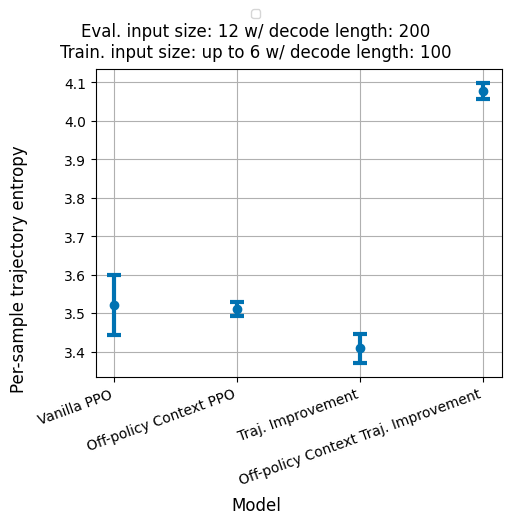

In [ ]:
num_cols = 1
num_rows = 1
fig, axes = plt.subplots(num_rows, num_cols, layout="constrained", figsize=(5.0 * num_cols, 5.0 * num_rows))

axes.errorbar(
    np.arange(len(res)),
    res[:, 0],
    yerr=np.array([res[:, 1], res[:, 2]]),
    fmt='o',
    elinewidth=3,
    capthick=3,
    errorevery=1,
    capsize=5,
)
axes.set_xticks(np.arange(len(res)), exp_names, rotation=20, ha="right")

print(hide_question)
axes.grid(True)
fig.supylabel("Per-sample trajectory entropy")
fig.supxlabel("Model")
fig.suptitle("Eval. input size: {} w/ decode length: {}\nTrain. input size: up to {} w/ decode length: {}".format(
    max_bits,
    max_response_length,
    train_num_bits,
    train_max_decode_len,
))
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=5,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

### Check first bit that's incorrect

/tmp/ipykernel_3358866/3991252856.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(


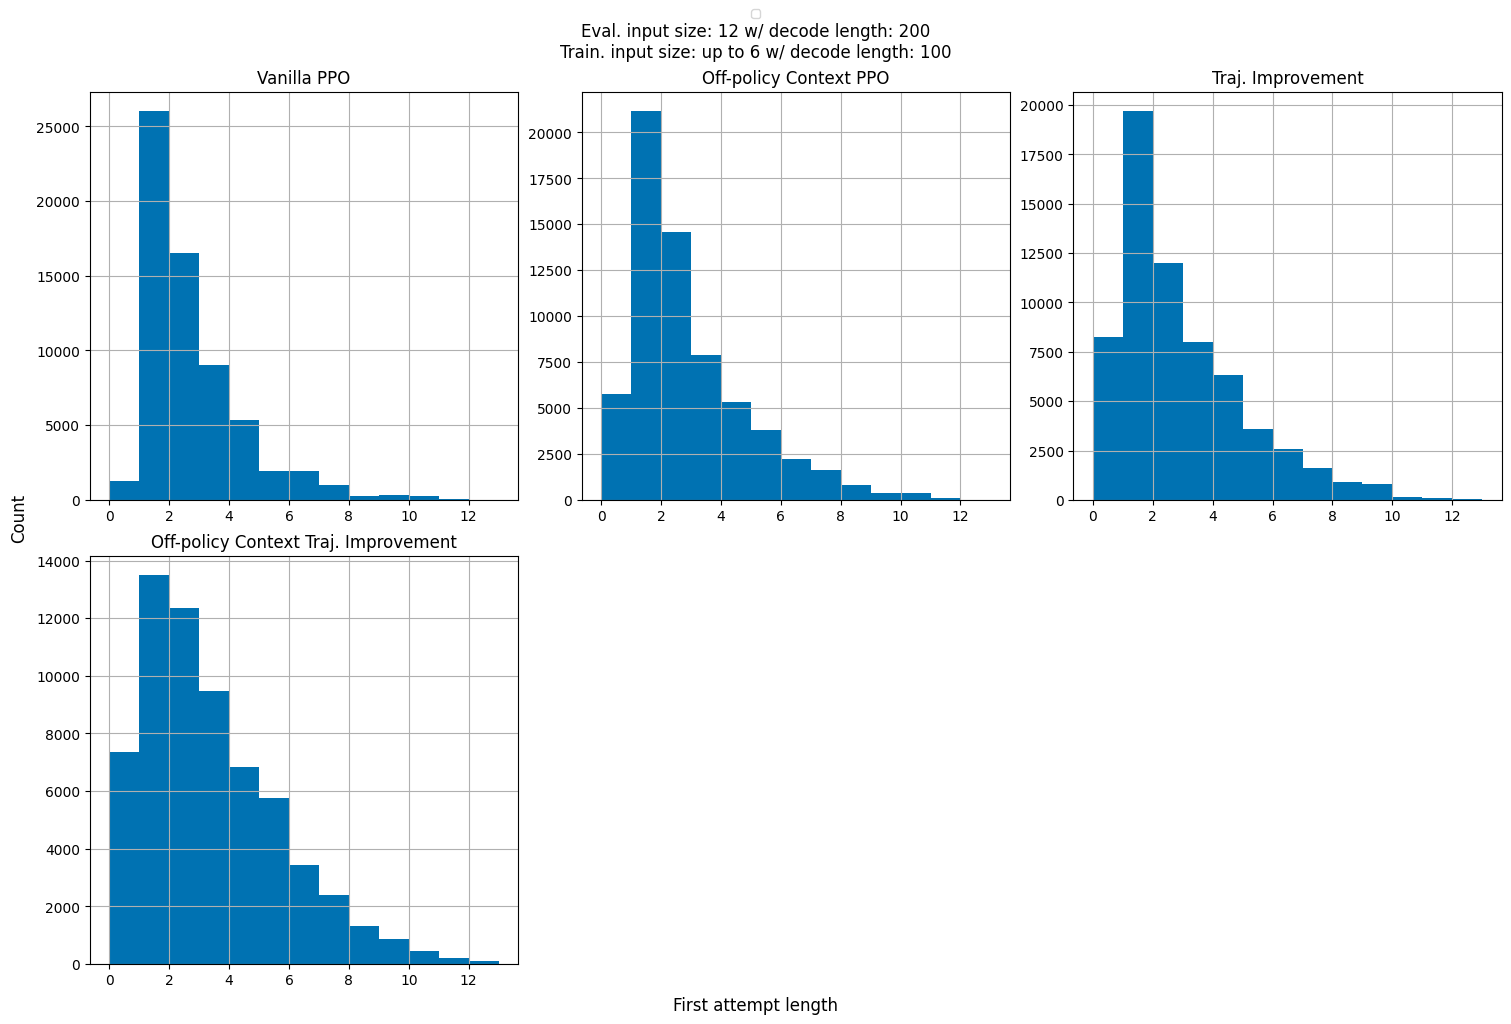

In [ ]:
# TODO: Display both hide and with questions

question_len = 0 if hide_question else 2 * max_bits + 1
num_cols = 3
num_rows = math.ceil(len(run_names) / 3)
fig, axes = plt.subplots(num_rows, num_cols, layout="constrained", figsize=(5.0 * num_cols, 5.0 * num_rows))

axes = axes.flatten()
for i, exp_name in enumerate(run_names):
    curr_exp_res = results[exp_name]
    curr_pred_mask = np.copy(curr_exp_res[2].reshape((batch_size, num_evals, -1)))
    curr_pred_mask[..., :question_len] = 1
    curr_traj = np.copy(curr_exp_res[1].reshape((batch_size, num_evals, -1)))
    curr_traj[np.logical_not(curr_pred_mask)] = dataset.eos_token_id

    reset_mask = (curr_traj == dataset.reset_token_id)[..., question_len:]
    reset_mask[..., 0] = False
    first_attempt_length = np.argmax(reset_mask, axis=-1)
    axes[i].hist(first_attempt_length.reshape(-1), bins=np.arange(0, 14))
    axes[i].set_title(exp_name)
    axes[i].grid(True)

for i in range(len(run_names), num_cols * num_rows):
    axes[i].axis("off")
fig.supylabel("Count")
fig.supxlabel("First attempt length")
fig.suptitle("Eval. input size: {} w/ decode length: {}\nTrain. input size: up to {} w/ decode length: {}".format(
    max_bits,
    max_response_length,
    train_num_bits,
    train_max_decode_len,
))
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=3,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

### Per-stage trajectory entropy

In [ ]:
results.keys()

dict_keys(['BFS', 'Train on subset', 'Default', 'Discourage first reset'])

In [ ]:
curr_exp_result = results["Save all attempts"]
question_len = 0 if hide_question else 2 * max_bits + 1
curr_pred_mask = np.copy(curr_exp_result[2].reshape((batch_size, num_evals, -1)))
curr_pred_mask[..., :question_len] = 1
curr_traj = np.copy(curr_exp_result[1].reshape((batch_size, num_evals, -1)))
curr_traj[np.logical_not(curr_pred_mask)] = dataset.eos_token_id

reset_idxes = np.where(curr_traj == dataset.reset_token_id)

In [ ]:
def get_attempt_reset_idxes(sample_i, traj_i):
    sample_reset_idxes = reset_idxes[0] == sample_i
    traj_reset_idxes = reset_idxes[1][sample_reset_idxes] == traj_i
    attempt_reset_idxes = reset_idxes[2][sample_reset_idxes][traj_reset_idxes]
    attempt_reset_idxes = np.concatenate((attempt_reset_idxes, [np.argmax(curr_traj[sample_i, traj_i]) + 1]))
    return attempt_reset_idxes[:-1], attempt_reset_idxes[1:]

In [ ]:
all_trajs = [
    [
        ["".join(map(lambda x: str(x), curr_traj[sample_i, traj_i][start_idx:end_idx])) for start_idx, end_idx in zip(
            *get_attempt_reset_idxes(sample_i, traj_i))]
        for traj_i in range(num_evals)
    ]
    for sample_i in range(batch_size)
]


In [ ]:
[
    [
        np.unique(list(filter(lambda x: x != "", curr_traj)), return_index=True)
        for traj_i, curr_traj in enumerate(curr_sample) if not curr_exp_result[0][0].reshape(batch_size, num_evals)[sample_i, traj_i]
    ]
    for sample_i, curr_sample in enumerate(all_trajs)
]

In [ ]:
entropies = [
    [
        scipy.stats.entropy(np.unique(list(filter(lambda x: x != "", curr_traj)), return_counts=True)[1])
        for curr_traj in curr_sample
    ]
    for curr_sample in all_trajs
]

In [ ]:
entropies = np.array(entropies)

In [ ]:
entropies[np.logical_not(curr_exp_result[0][0].reshape(batch_size, num_evals))]

In [ ]:
np.mean(entropies, axis=-1)[np.max(curr_exp_result[0][0].reshape(batch_size, num_evals), axis=-1).astype(bool)]

In [ ]:
np.mean(entropies, axis=-1)[np.logical_not(np.max(curr_exp_result[0][0].reshape(batch_size, num_evals), axis=-1))]

In [ ]:
assert 0

## Policy Entropy

In [ ]:
if os.path.isfile(logits_save_name):
    results = dill.load(open(logits_save_name, "rb"))
else:
    results = dict()

    for batch_i in tqdm(range(batch_size // batch_size_per_block)):
        batch = next(data_iter)

        if hide_question:
            batch["sequence"][:] = dataset.reset_token_id
            batch["mask"][:] = 1
            batch["question_len"][:] = 0

        batch = {
            k: np.repeat(v, num_evals, axis=0)
            for k, v in batch.items()
        }

        curr_result = compute_expected_trials(batch_i, batch)
        curr_result = np.vstack((
            np.array(curr_result[1] <= max_response_length),
            np.array(curr_result[1]),
            np.array(curr_result[0]),
        ), dtype=int)
        if batch_i == 0:
            results["BFS"] = curr_result
        else:
            results["BFS"] = jnp.hstack((results["BFS"], curr_result))

        for exp_name, run_name in run_names.items():
            learner_path = os.path.join(base_path, algo_name, run_name)
            config_dict = json.load(open(os.path.join(learner_path, "config.json"), "r"))

            # Load model
            last_step = sorted(os.listdir(os.path.join(learner_path, "models")))[checkpoint_i]
            if batch_i == 0:
                print(exp_name, last_step)
            train_state = dill.load(
                open(os.path.join(learner_path, "models", last_step), "rb")
            )

            model = nnx.merge(
                train_state.graphdef,
                train_state.params,
                train_state.rest,
            )

            rng = jax.random.PRNGKey(eval_seed)
            rng, rollout_rng = jax.random.split(rng)

            # Sample next batch and evaluate
            _, init_cache = make_autoregressive(
                model,
                max_decode_len=max_decode_len,
                batch_size=batch_size_per_block * num_evals,
                embed_dim=config_dict["model_config"]["model_kwargs"]["embed_dim"],
                dtype=dtype,
                eval_mode=True,
            )
            cache = init_cache()
            graphdef, _, rest = nnx.split(model, nnx.Cache, ...)

            rollout_res = rollout_with_logits(
                graphdef,
                cache,
                rest,
                rollout_rng,
                batch,
                eos_token=dataset.eos_token_id,
                out_dim=out_dim,
                deterministic=int(num_evals == 1),
                correct_aware_shift=dataset.correctness_aware_tokens_offset,
                max_token_id_to_shift=dataset.max_token_id_to_shift,
            )

            num_resets = np.sum((rollout_res.observations * rollout_res.pred_mask) == dataset.reset_token_id, axis=-1)

            curr_result = np.vstack((
                np.array(rollout_res.success),
                np.array(rollout_res.response_length),
                np.array(num_resets),
            ), dtype=int)
            if batch_i == 0:
                results[exp_name] = (curr_result, np.array(rollout_res.logits))
            else:
                results[exp_name] = (
                    np.hstack((results[exp_name][0], curr_result)),
                    np.concatenate((results[exp_name][1], np.array(rollout_res.logits)), axis=0)
                )

    dill.dump(
        results,
        open(logits_save_name, "wb"),
    )

  0%|          | 0/10 [00:00<?, ?it/s]

Vanilla PPO 1000000.dill
Off-policy Context PPO 1000000.dill
Traj. Improvement 1000000.dill
Off-policy Context Traj. Improvement 1000000.dill


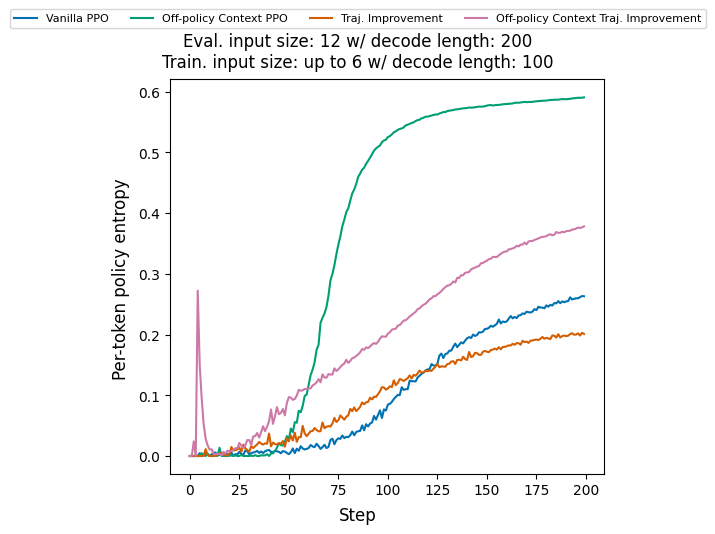

In [ ]:
question_len = max_bits * 2 + 1
num_cols = 1
num_rows = 1
fig, axes = plt.subplots(num_rows, num_cols, layout="constrained", figsize=(5.0 * num_cols, 5.0 * num_rows))

for exp_name, curr_exp_res in results.items():
    if exp_name == "BFS":
        continue
    logits = results[exp_name][1]
    entropies = optax.softmax_cross_entropy(logits, jax.nn.softmax(logits, axis=-1))
    # TODO: exlude outputs after completion
    mean_entropies = np.mean(entropies, axis=0)[question_len:]
    plt.plot(
        np.arange(len(mean_entropies)),
        mean_entropies,
        label=exp_name
    )

fig.supylabel("Per-token policy entropy")
fig.supxlabel("Step")
fig.suptitle("Eval. input size: {} w/ decode length: {}\nTrain. input size: up to {} w/ decode length: {}".format(
    max_bits,
    max_response_length,
    train_num_bits,
    train_max_decode_len,
))
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=5,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

In [ ]:
assert 0

AssertionError: 

## TODO:
- Success rate at OOD context length (not the question length, but context usage)
- Is the decoding biased towards 1? If there's a lot of 1s in the solution then success rate is high?
- A new MDP where we only provide the best responsea and failed action so far as the context?
- Perhaps there's some entropy tradeoff here... Double check OPC traj. improve. ablation.